In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
#from GEOS5functions import *
import datetime
from scipy.ndimage import rotate
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [2]:
%run GEOS5functions.py
%matplotlib inline 

In [3]:
#variables listed here: https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst

# List of variable names to retrieve from the dataset
varvec = ['U', 'V', 'DELP', 'T', 'PL', 'H', 'SO4', 'SO2','BCPHILIC','BCPHOBIC', 'CLOUD', 'DU001', 'DU005', 'OCPHILIC', 'OCPHOBIC', 'SS001', 'SS005', 'EPV']

# Iterate over each variable name in varvec
for vind in range(len(varvec)):
    # Construct the URL for accessing the dataset corresponding to the current variable
    url = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_3d_' + varvec[vind] + '_Nv'
    
    # Open the dataset for the current variable based on the variable name
    if varvec[vind] == 'U':
        dsu = xr.open_dataset(url)  
    if varvec[vind] == 'V':
        dsv = xr.open_dataset(url) 
    if varvec[vind] == 'SO4':
        dsso4 = xr.open_dataset(url)
    if varvec[vind] == 'SO2':
        dsso2 = xr.open_dataset(url)
    if varvec[vind] == 'BCPHOBIC':
        dsbcphobic = xr.open_dataset(url)
    if varvec[vind] == 'BCPHILIC':
        dsbcphilic = xr.open_dataset(url)
    if varvec[vind] == 'DU001':
        dsdu001 = xr.open_dataset(url)
    if varvec[vind] == 'CLOUD':
        dscloud = xr.open_dataset(url)
    if varvec[vind] == 'DU005':
        dsdu005 = xr.open_dataset(url)
    if varvec[vind] == 'OCPHILIC':
        dsocphilic = xr.open_dataset(url)
    if varvec[vind] == 'OCPHOBIC':
        dsocphobic = xr.open_dataset(url)
    if varvec[vind] == 'SS001':
        dsss001 = xr.open_dataset(url)
    if varvec[vind] == 'SS005':
        dsss005 = xr.open_dataset(url)
    if varvec[vind] == 'EPV':
        dsepv = xr.open_dataset(url)


# Print a success message indicating that the datasets have been read successfully
print('success reading')



/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-pack

success reading


In [5]:
# Retrieve the list of all storms using the getallstorms function
stormlist = getallstorms()

In [9]:
coastal = np.concatenate([
    [1, 11, 20, 22, 24],
    np.arange(26, 36),
    [37, 42, 44],
    np.arange(45, 54),
    [55, 59, 60, 62, 64, 65, 67, 68, 71],
    np.arange(75, 91),
    [98],
    np.arange(100, 108),
    np.arange(114, 125),
    np.arange(125, 133),
    [134, 135, 136, 141, 148],
    np.arange(152, 157),
    np.arange(159, 160),
    [161]
])
ocean = np.concatenate([
    [0],
    np.arange(2, 11),
    np.arange(12, 20),
    [21, 23, 25, 36, 38, 39, 40, 41, 43, 57, 61, 63, 66, 69, 70, 72, 73, 74, 91, 93, 94, 96, 97],
    np.arange(108, 111),
    np.arange(112, 114),
    [ 133, 137, 165, 166]
])

all_of_all =  np.concatenate([coastal, ocean])

In [10]:
#coasteal_selected = [1, 11, 20, 44, 62, 106, 134, 157]
#ocean_selected = [5, 8, 16, 23, 61, 73, 159]
#all_tc = [1, 11, 20, 44, 62, 106, 134, 157, 5, 8, 16, 23, 61, 73, 159]

In [11]:
len(all_of_all)

142

In [12]:
all_tc = all_of_all

so4
atl05tc01
1
atl05tc02
11
atl05tc12
20
atl06tc04
22
atl06tc06
24
atl06tc08
26
atl06tc10
27
epc05tc01
28
epc05tc02
29
epc05tc03
30
epc05tc04
31
epc05tc05
32
epc05tc06
33
epc05tc07
34
epc05tc08
35
epc06tc01
37
epc06tc03
42
epc06tc08
44
epc06tc10
45
epc06tc11
46
epc06tc12
47
epc06tc13
48
epc06tc14
49
epc06tc15
50
epc06tc16
51
epc06tc17
52
epc06tc18
53
epc06tc19
55
npc05tc02
59
npc05tc06
60
npc05tc07
62
npc05tc09
64
npc05tc11
65
npc05tc12
67
npc05tc14
68
npc05tc15
71
npc05tc18
75
npc05tc22
76
npc05tc23
77
npc06tc01
78
npc06tc02
79
npc06tc03
80
npc06tc04
81
npc06tc05
82
npc06tc06
83
npc06tc07
84
npc06tc08
85
npc06tc09
86
npc06tc10
87
npc06tc11
88
npc06tc12
89
npc06tc13
90
npc06tc14
98
nio05tc01
100
nio05tc03
101
nio05tc04
102
nio06tc01
103
nio06tc02
104
nio06tc03
105
nio06tc04
106
nio06tc05
107
nio06tc06
114
sio56tc07
115
sio56tc08
116
sio56tc09
117
sio56tc10
118
sio56tc11
119
sio56tc12
120
sio56tc13
121
sio56tc14
122
sio56tc15
123
sio56tc16
124
sio56tc17
125
sio56tc18
126
sio67tc01
127


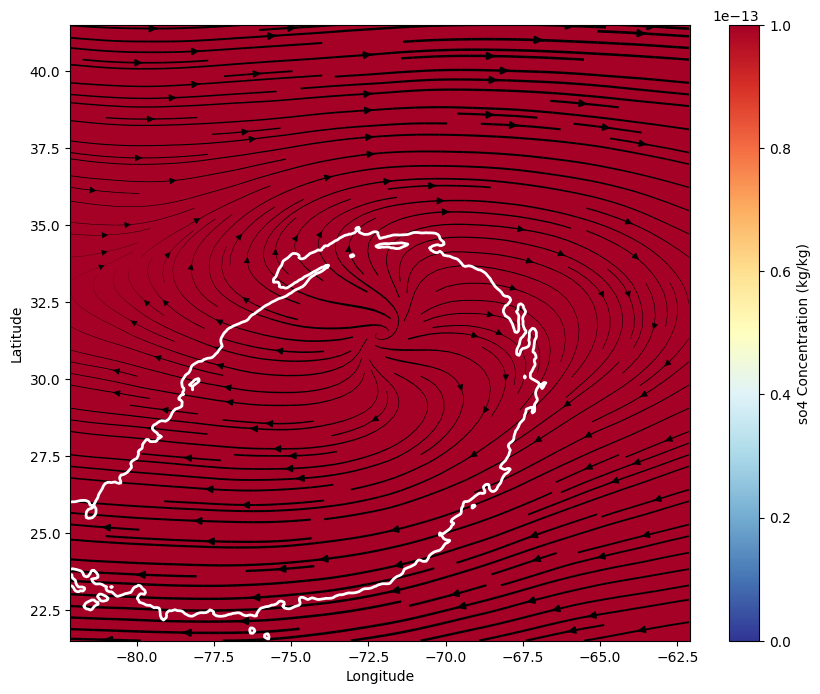

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# Function to create plots for different variables
def create_plot(variable_sel_avg, variable_name, usel_avg, vsel_avg):
    low_value_threshold = np.percentile(variable_sel_avg.values, 30)  # Example: values below the 40th percentile

    # Calculate wind speed
    wind_speed = np.sqrt(usel_avg**2 + vsel_avg**2)

    # Streamlines
    # Adjust linewidth based on wind speed (normalize it)
    u_selected_np = usel_avg.values
    v_selected_np = vsel_avg.values
    wind_speed_np = wind_speed.values

    fig, ax = plt.subplots(figsize=(10, 8))
    
    strm = ax.streamplot(variable_sel_avg.lon.values, variable_sel_avg.lat.values, u_selected_np, v_selected_np, 
                         color='black', linewidth=2 * wind_speed_np / wind_speed_np.max(), density=1.8)

    flux_min = 0 # so4.where(so4 > 0).min().item()  # Avoid zero values
    flux_max = 1 * 1e-13 # so4.where(so4 > 0).max().item()
    

    contour = ax.pcolormesh(variable_sel_avg.lon, variable_sel_avg.lat, variable_sel_avg, cmap='RdYlBu_r', norm=mcolors.Normalize(vmin= flux_min, vmax= flux_max))
    fig.colorbar(contour, ax=ax, label=f'{variable_name} Concentration (kg/kg)')

    low_value_contour = ax.contour(variable_sel_avg.lon, variable_sel_avg.lat, variable_sel_avg, levels=[low_value_threshold], colors='white', linewidths=2)

    ax.set_ylim(variable_sel_avg.lat.min(), variable_sel_avg.lat.max())
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    plt.savefig(f'{variable_name}_Concentration_lat_out_20_20all_of_allwidth{str(degbuffer)}.png', bbox_inches='tight', transparent=True)
    plt.show()
    
    # Calculate angular differences between wind direction and contour tangent
    #calculate_angular_differences(variable_sel_avg, u_selected_np, v_selected_np, low_value_contour)

# Function to calculate and plot angular differences
'''
def calculate_angular_differences(variable_sel, u_selected_np, v_selected_np, low_value_contour):
    # Create interpolators for the wind components
    wind_interp_u = RegularGridInterpolator((variable_sel.lat.values, variable_sel.lon.values), u_selected_np)
    wind_interp_v = RegularGridInterpolator((variable_sel.lat.values, variable_sel.lon.values), v_selected_np)
    
    # Initialize a list to store angular differences
    angle_differences = []
    
    # Loop through each contour collection
    for collection in low_value_contour.collections:
        # Each collection may contain multiple paths (segments)
        for path in collection.get_paths():
            vertices = path.vertices  # vertices is an (N, 2) array: columns are [lon, lat]
            if len(vertices) < 2:
                continue  # need at least two points to compute a tangent
                
            # Compute tangent angles using finite differences
            # Calculate differences between consecutive points
            dlon = np.diff(vertices[:, 0])
            dlat = np.diff(vertices[:, 1])
            
            # Compute the tangent angle at each segment (radians)
            tangent_angles = np.arctan2(dlat, dlon)
            
            # For each vertex, assign a tangent angle
            # For the last vertex, reuse the previous segment's tangent
            tangent_angles = np.concatenate([tangent_angles, [tangent_angles[-1]]])
            
            # Interpolate wind vectors at the contour vertices:
            # Note: the interpolator expects (lat, lon) order
            wind_points = vertices[:, [1, 0]]
            
            try:
                local_u = wind_interp_u(wind_points)
                local_v = wind_interp_v(wind_points)
                
                # Compute wind angles at these points
                wind_angles = np.arctan2(local_v, local_u)
                
                # Compute the absolute difference between wind direction and tangent direction
                # Adjust for circularity (angles in radians; differences > pi/2 are folded)
                diff = np.abs(wind_angles - tangent_angles)
                diff = np.where(diff > np.pi, 2*np.pi - diff, diff)
                diff = np.where(diff > np.pi/2, np.pi - diff, diff)
                
                angle_differences.extend(diff)
            except:
                print("Warning: Some points were outside the interpolation domain")
    
    if angle_differences:
        # Convert to a numpy array for further analysis
        angle_differences = np.array(angle_differences)
        
        # Plot a histogram of the angular differences (in degrees)
        plt.figure(figsize=(8, 5))
        plt.hist(np.degrees(angle_differences), bins=9, edgecolor='k', alpha=0.7, density=True)
        plt.xlabel('Angular Difference (degrees)')
        plt.ylabel('Normalized Frequency')
        plt.title('Distribution of Angular Differences\nbetween Wind Direction and Contour Tangent')
        plt.show()
    else:
        print("No valid angle differences calculated")
'''
# List of variables to plot
variables = [ 'so4' ]

for variable in variables:
    print(variable)
    currentstorm = 0

    starttime = stormlist[3][currentstorm]
    endtime   = stormlist[4][currentstorm]
    lat1  = stormlist[5][currentstorm]
    lat2  = stormlist[6][currentstorm]
    lon1  = stormlist[7][currentstorm]
    lon2  = stormlist[8][currentstorm]

    timesel = slice(starttime, endtime)
    degbuffer = 10
    buffer = degbuffer

    stormname = stormlist[1][currentstorm][0:9]
    print(stormname)

    stormtraj = np.load('/home/modares/TC/trajectory/' + str(stormname) + '.npz')
    minpres = stormtraj['minpres']
    timee = stormtraj['time']
    minplat = stormtraj['minplat']
    minplon = stormtraj['minplon']

    # Finding time of minpres
    #min_time = timee[minpres.argmin()]
    min_time = timee[-1]

    
    latsel = slice(minplat[minpres.argmin()] - buffer, minplat[minpres.argmin()] + buffer)
    lonsel = slice(minplon[minpres.argmin()] - buffer, minplon[minpres.argmin()] + buffer)

    variable_data = eval(f'ds{variable}["{variable}"]').sel(time= min_time, lat=latsel, lon=lonsel)

    lat_common = variable_data.coords['lat'].values
    lon_common = variable_data.coords['lon'].values

    usel_sum = 0
    vsel_sum = 0
    variable_sel_sum = 0

    for i in all_tc:
        currentstorm = i
        print(i)
        
        starttime = stormlist[3][currentstorm]
        endtime   = stormlist[4][currentstorm]
        lat1  = stormlist[5][currentstorm]
        lat2  = stormlist[6][currentstorm]
        lon1  = stormlist[7][currentstorm]
        lon2  = stormlist[8][currentstorm]
        
        timesel = slice(starttime, endtime)
        degbuffer = degbuffer
        stormname = stormlist[1][currentstorm][0:9]
        print(stormname)
        
        stormtraj = np.load('/home/modares/TC/trajectory/' + str(stormname) + '.npz')
        minpres = stormtraj['minpres']
        timee = stormtraj['time']
        minplat = stormtraj['minplat']
        minplon = stormtraj['minplon']
        
        # Finding time of minpres
        min_time = timee[minpres.argmin()]
        
        latsel = slice(minplat[minpres.argmin()] - buffer, minplat[minpres.argmin()] + buffer)
        lonsel = slice(minplon[minpres.argmin()] - buffer, minplon[minpres.argmin()] + buffer)
        
        # Selecting datasets
        leve = 40
        variable_data = eval(f'ds{variable}["{variable}"]').sel(time= min_time, lat=latsel, lon=lonsel, lev=leve)
        uwind = dsu['u'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
        vwind = dsv['v'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
        '''
        if 20 < np.mean(variable_data.lat.values) or np.mean(variable_data.lat.values) < -20:
            print('continue')
            continue
        '''
        if np.mean(variable_data.lat.values) < 0:
            variable_data = variable_data.sel(lat=slice(None, None, -1))
            uwind = uwind.sel(lat=slice(None, None, -1))
            vwind = vwind.sel(lat=slice(None, None, -1))

        variable_sel = variable_data.assign_coords(lat=lat_common, lon=lon_common)
        usel = uwind.assign_coords(lat=lat_common, lon=lon_common)
        vsel = vwind.assign_coords(lat=lat_common, lon=lon_common)
        
        # Plot ###################
        low_value_threshold = np.percentile(variable_sel.values, 30)  # Example: values below the 40th percentile
        
        # Visualization in the original loop is moved to the create_plot function
        # Only red contours are added here to the cumulative plot
        fig, ax = plt.subplots(figsize=(10, 8))
        low_value_contour = ax.contour(variable_sel.lon, variable_sel.lat, variable_sel, levels=[low_value_threshold], colors='red', linewidths=0.00)
        plt.close(fig)  # Close this figure as it's just temporary
        
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        
        variable_sel_sum += variable_sel
        usel_sum += usel
        vsel_sum += vsel
        
    variable_sel_avg = variable_sel_sum / len(all_tc) 
    usel_avg = usel_sum / len(all_tc) 
    vsel_avg = vsel_sum / len(all_tc) 

    # Create the final plot with average values and calculate angular differences
    create_plot(variable_sel_avg, variable, usel_avg, vsel_avg)

In [20]:
variable_sel_avg.min()

<xarray.DataArray 'so4' ()> Size: 4B
array(3.2080255e-11, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2005-08-16T12:00:00
    lev      float64 8B 40.0

# Plot

In [21]:

#pv_sel_avg = variable_sel_avg * 1e+6 # PV

variable_sel_avg = variable_sel_avg * ( (28.96/96.06) * 1e+6) # SO4

#variable_sel_avg = variable_sel_avg * (28.96/64.066) * 1e+6 # SO2

#cloudsel_avg = variable_sel_avg


In [35]:
low_value_threshold_so4 = np.percentile(variable_sel_avg.values, 33.3)  # Example: values below the 40th percentile
low_value_threshold_so4 = 4 * 1e-5

In [36]:
low_value_threshold_cloud = np.percentile(cloudsel_avg.values, 90)  # Example: values below the 40th percentile


In [37]:
#low_value_threshold_pv = np.percentile(pv_sel_avg.values, 6.35)  # Example: values below the 40th percentile
low_value_threshold_pv = 0

In [38]:
low_value_threshold_pv

0

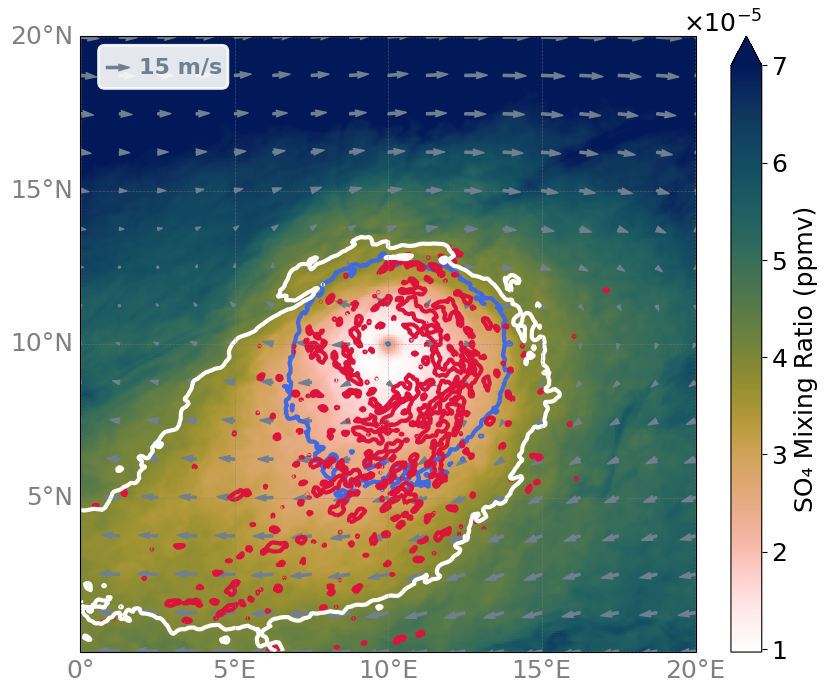

In [33]:
from matplotlib.patches import FancyBboxPatch
from scipy.ndimage import gaussian_filter
import colormaps as cmaps 
import matplotlib.ticker as mticker


low_value_threshold = low_value_threshold_so4 #np.percentile(variable_sel_avg.values, 30)  # Example: values below the 40th percentile

from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
mpl.rcParams.update({'font.size': 18})  # Change 12 to your preferred base size


fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.PlateCarree()})


# Calculate wind speed
wind_speed = np.sqrt(usel_avg**2 + vsel_avg**2)

# Streamlines
u_selected_np = usel_avg.values
v_selected_np = vsel_avg.values
wind_speed_np = wind_speed.values

artificial_lat = np.linspace(0, 20, variable_sel_avg.lat.size)
artificial_lon = np.linspace(0, 20, variable_sel_avg.lon.size)



flux_min = variable_sel_avg.where(variable_sel_avg > -5 * 1e-6).min().item()  # Avoid zero values
flux_max = 7* 1e-5# variable_sel_avg.where(variable_sel_avg > 0).max().item()
contour = ax.pcolormesh(artificial_lon, artificial_lat, variable_sel_avg, cmap=cmaps.batloww_r, norm=mcolors.Normalize(vmin= flux_min, vmax= flux_max))
# LogNorm
# Normalize

#contour = ax.contourf(so4.lon, so4.lat, so4, levels=20, cmap='viridis')
cbar1 = fig.colorbar(contour, ax=ax, label='SO₄ Mixing Ratio (ppmv)', extend='max', pad=0.03 )

# Set scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))  # Forces scientific notation for small/large values
cbar1.ax.yaxis.set_major_formatter(formatter)



#strm = ax.streamplot(artificial_lon, artificial_lat, u_selected_np, v_selected_np, color='w', linewidth=3 * wind_speed_np / wind_speed_np.max(), density=1.4)






### Quiver
# Quiver plot
step = 20
Q = ax.quiver(
    artificial_lon[::step], 
    artificial_lat[::step], 
    u_selected_np[::step, ::step], 
    v_selected_np[::step, ::step], 
    scale=400,
    width=0.0035,
    color='slategrey',  # White arrows stand out better on viridis
    edgecolors='slategrey',  # Add edge for better visibility
    linewidths=1
)

# Add quiver key (scale reference)
qk = ax.quiverkey(Q, 0.08, 0.95,  # X, Y position (in axes coordinates, 0-1)
             15,  # Reference vector magnitude (e.g., 10 m/s)
             '15 m/s',  # Label
             labelpos='E',  # Label position: 'N', 'S', 'E', 'W'
             coordinates='axes',
             color='slategrey',
             labelcolor='slategrey',
             fontproperties={'size': 16, 'weight': 'bold'})

# Add a box around both the arrow and text
# Position and size may need adjustment based on your figure
box = FancyBboxPatch((0.04, 0.9250),  # (x, y) lower-left corner in axes coords
                     0.19, 0.05,     # width, height
                     boxstyle="round,pad=0.01",
                     edgecolor='w',
                     facecolor='w',
                     alpha=0.9,
                     linewidth=2,
                     transform=ax.transAxes,
                     zorder=2)  # Make sure box is behind quiver key
ax.add_patch(box)

# Adjust quiver key zorder to appear on top of box
qk.set_zorder(3)

### End Quiver







pv_smoothed = gaussian_filter(pv_sel_avg.values, sigma=0)


low_value_contour = ax.contour(artificial_lon, artificial_lat, cloudsel_avg, levels=[low_value_threshold_cloud], colors='royalblue', linewidths=3)



low_value_contour = ax.contour(artificial_lon, artificial_lat, pv_smoothed, levels=[low_value_threshold_pv], colors='crimson', linewidths=3,linestyles='-')



# Smooth the data (adjust sigma for more/less smoothing)
so4_smoothed = gaussian_filter(variable_sel_avg.values, sigma=0)

# Use the smoothed data in your contour
low_value_contour = ax.contour(artificial_lon, artificial_lat, so4_smoothed, levels=[low_value_threshold], 
                               colors='w', linewidths=3,linestyles='-')





# Gridlines and axis formatting
crs0 = ccrs.PlateCarree()
gl = ax.gridlines(
    crs=crs0,
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# Turn off top and right labels
gl.top_labels = False     # no x-labels on top
gl.right_labels = False   # no y-labels on right

# Keep bottom and left labels (default is True)
gl.bottom_labels = True
gl.left_labels = True

# Style
gl.ylocator = mticker.FixedLocator([0, 5, 10, 15, 20])
gl.xlocator = mticker.FixedLocator([0, 5, 10, 15, 20])
gl.xlabel_style = {'size': 18, 'color': 'gray'}
gl.ylabel_style = {'size': 18, 'color': 'gray'}

#ax.set_xlabel('Longitude', fontsize=12)
#ax.set_ylabel('Latitude')

#ax.set_ylim(minplat[arg] - buffer, minplat[arg] + buffer)
#ax.set_xlim(minplon[arg] - buffer, minplon[arg] + buffer)



#plt.savefig(f'avg_{variables}_' + f'{stormname}' + '_width_' + str(buffer)  + 'allofall' + '_colorblind_q_final.png', bbox_inches='tight', transparent=True)
plt.show()    


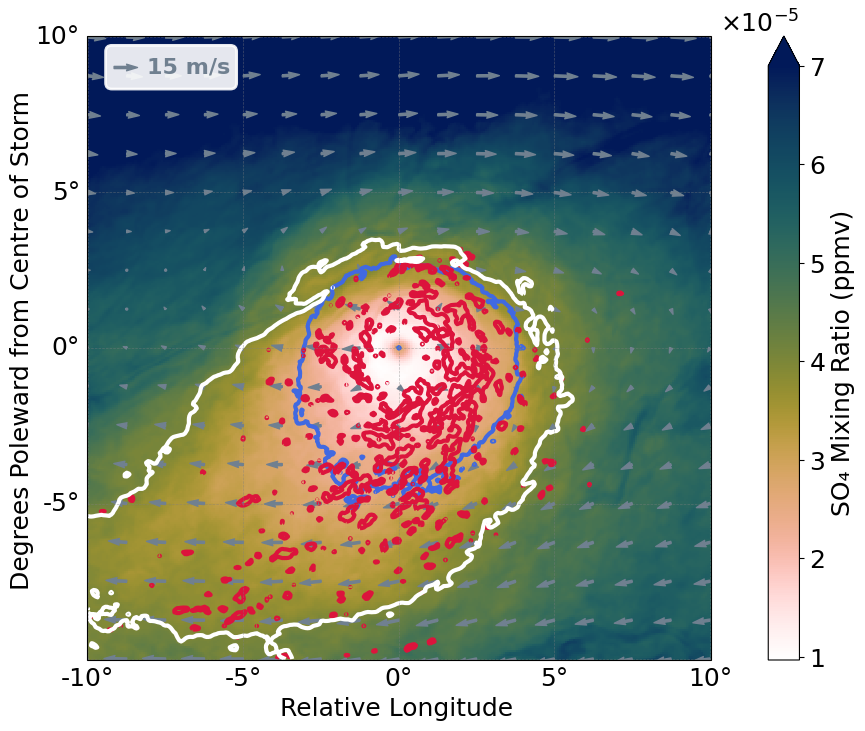

In [79]:
from matplotlib.patches import FancyBboxPatch
from scipy.ndimage import gaussian_filter
import colormaps as cmaps 
import matplotlib.ticker as mticker


low_value_threshold = low_value_threshold_so4 #np.percentile(variable_sel_avg.values, 30)  # Example: values below the 40th percentile

from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
mpl.rcParams.update({'font.size': 18})  # Change 12 to your preferred base size


fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.PlateCarree()})


# Calculate wind speed
wind_speed = np.sqrt(usel_avg**2 + vsel_avg**2)

# Streamlines
u_selected_np = usel_avg.values
v_selected_np = vsel_avg.values
wind_speed_np = wind_speed.values

artificial_lat = np.linspace(0, 20, variable_sel_avg.lat.size)
artificial_lon = np.linspace(0, 20, variable_sel_avg.lon.size)



flux_min = variable_sel_avg.where(variable_sel_avg > -5 * 1e-6).min().item()  # Avoid zero values
flux_max = 7* 1e-5# variable_sel_avg.where(variable_sel_avg > 0).max().item()
contour = ax.pcolormesh(artificial_lon, artificial_lat, variable_sel_avg, cmap=cmaps.batloww_r, norm=mcolors.Normalize(vmin= flux_min, vmax= flux_max))
# LogNorm
# Normalize

#contour = ax.contourf(so4.lon, so4.lat, so4, levels=20, cmap='viridis')
cbar1 = fig.colorbar(contour, ax=ax, label='SO₄ Mixing Ratio (ppmv)', extend='max', pad=0.015 )

# Set scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))  # Forces scientific notation for small/large values
cbar1.ax.yaxis.set_major_formatter(formatter)



#strm = ax.streamplot(artificial_lon, artificial_lat, u_selected_np, v_selected_np, color='w', linewidth=3 * wind_speed_np / wind_speed_np.max(), density=1.4)






### Quiver
# Quiver plot
step = 20
Q = ax.quiver(
    artificial_lon[::step], 
    artificial_lat[::step], 
    u_selected_np[::step, ::step], 
    v_selected_np[::step, ::step], 
    scale=400,
    width=0.0035,
    color='slategrey',  # White arrows stand out better on viridis
    edgecolors='slategrey',  # Add edge for better visibility
    linewidths=1
)

# Add quiver key (scale reference)
qk = ax.quiverkey(Q, 0.08, 0.95,  # X, Y position (in axes coordinates, 0-1)
             15,  # Reference vector magnitude (e.g., 10 m/s)
             '15 m/s',  # Label
             labelpos='E',  # Label position: 'N', 'S', 'E', 'W'
             coordinates='axes',
             color='slategrey',
             labelcolor='slategrey',
             fontproperties={'size': 16, 'weight': 'bold'})

# Add a box around both the arrow and text
# Position and size may need adjustment based on your figure
box = FancyBboxPatch((0.04, 0.9250),  # (x, y) lower-left corner in axes coords
                     0.19, 0.05,     # width, height
                     boxstyle="round,pad=0.01",
                     edgecolor='w',
                     facecolor='w',
                     alpha=0.9,
                     linewidth=2,
                     transform=ax.transAxes,
                     zorder=2)  # Make sure box is behind quiver key
ax.add_patch(box)

# Adjust quiver key zorder to appear on top of box
qk.set_zorder(3)

### End Quiver







pv_smoothed = gaussian_filter(pv_sel_avg.values, sigma=0)


low_value_contour = ax.contour(artificial_lon, artificial_lat, cloudsel_avg, levels=[low_value_threshold_cloud], colors='royalblue', linewidths=3)



low_value_contour = ax.contour(artificial_lon, artificial_lat, pv_smoothed, levels=[low_value_threshold_pv], colors='crimson', linewidths=3,linestyles='-')



# Smooth the data (adjust sigma for more/less smoothing)
so4_smoothed = gaussian_filter(variable_sel_avg.values, sigma=0)

# Use the smoothed data in your contour
low_value_contour = ax.contour(artificial_lon, artificial_lat, so4_smoothed, levels=[low_value_threshold], 
                               colors='w', linewidths=3,linestyles='-')





# Gridlines and axis formatting
crs0 = ccrs.PlateCarree()
gl = ax.gridlines(
    crs=crs0,
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# Turn off top and right labels
gl.top_labels = False     # no x-labels on top
gl.right_labels = False   # no y-labels on right

# Keep bottom and left labels (default is True)
gl.bottom_labels = True
gl.left_labels = True

# Style
offset_lat = 10  # shift south by 10
offset_lon = 10  # shift west by 10

gl.ylocator = mticker.FixedLocator([0, 5, 10, 15, 20])
gl.xlocator = mticker.FixedLocator([0, 5, 10, 15, 20])

gl.xformatter = mticker.FuncFormatter(lambda v, _: f'{int(v - offset_lon)}°')
gl.yformatter = mticker.FuncFormatter(lambda v, _: f'{int(v - offset_lat)}°')

gl.xlabel_style = {'size': 18, 'color': 'k'}
gl.ylabel_style = {'size': 18, 'color': 'k'}

fig.text(0.27, 0.03, 'Relative Longitude', 
         ha='center', fontsize=18, color='k')
fig.text(0.02, 0.5, 'Degrees Poleward from Centre of Storm', 
         ha='center', va='center', rotation='vertical', fontsize=18, color='k')

plt.subplots_adjust(left=-1.65, bottom=0.1)

#ax.set_xlabel('Longitude', fontsize=12)
#ax.set_ylabel('Latitude')

#ax.set_ylim(minplat[arg] - buffer, minplat[arg] + buffer)
#ax.set_xlim(minplon[arg] - buffer, minplon[arg] + buffer)



plt.savefig(f'avg_{variables}_' + f'{stormname}' + '_width_' + str(buffer)  + 'allofall' + '_colorblind_fromcentreofstorm.png', bbox_inches='tight', transparent=True)
plt.show()    
